#Inspect UMM Tokenizer Codes

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torchaudio
import IPython.display as ipd
assert torch.cuda.is_available()
import sys
import os
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
os.chdir('/opt/tiger/samantha')

In [4]:
from recipes.umm.models.dualumm_vector_quantizers import get_vq_codebook_distances
def get_codebook_magnitudes(codebook):
    return codebook.norm(p=2,dim=1)

# Define Models

In [139]:
from recipes.umm.requires.model_initializer import (init_stage3_conv1d, init_stage3, init_convumm_gan)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model_convumm_gan(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_convumm_gan(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3"
    ].eval()
    return token_model

def load_model_convumm_conv1D(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3_conv1d(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3Conv1D"
    ].eval()
    return token_model

def load_model_conformer(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3"
    ].eval()
    return token_model

def load_model_convumm_pitch(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3_conv1d(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3Conv1D"
    ].eval()
    return token_model 

MODELS_DICT = {
    # GROUP A
    # @hanoihantrakul: 2JUN2024 This is the latest ConvUMM-GAN trained on 2255 2375. These ones incorrectly used LAS loss and are depracted in master branch.
    "convumm_gan_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0590000.ckpt",
    "convumm_gan_2255_2375_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0100000.ckpt",
    "convumm_gan_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0010000.ckpt",
    
    # GROUP B
    # @hanoihantrakul: 22APR2024 This is the latest Direct Stage3 ConvUMM trained on 2255 2375
    "convumm_direct_stage3_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0310000.ckpt",
    "convumm_direct_stage3_2255_2375_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0100000.ckpt",
    "convumm_direct_stage3_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0010000.ckpt",
    # @hanoihantrakul: 26APR2024 This is the latest ConformerUMM trained on 2255 2375
    "conformerumm_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conformer_2255mixedZHEN_2375Speech/umm_stage3_2255mixedZHEN_2375Speech_optim_mem_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0180000.ckpt",
    "conformerumm_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conformer_2255mixedZHEN_2375Speech/umm_stage3_2255mixedZHEN_2375Speech_optim_mem_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0010000.ckpt",
    
    # Group C
    # @hanoihantrakul: OCT2023 Legacy ConformerUMM that was reference baseline for QQ L2S ZH. Remember though that his was trained with x4 instances.
    "legacy_conformerumm_l2s_zh": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm/umm_stage3_zh_dw1-1-0_wordpiece_vq32768x16-layer12/checkpoints/step=070000.ckpt",
     "legacy_conformerumm_l2s_zh_step10k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm/umm_stage3_zh_dw1-1-0_wordpiece_vq32768x16-layer12/checkpoints/step=010000.ckpt",
    # @hanoihantrakul: OCT2023 Legacy ConformerUMM that was reference baseline for QQ L2S ZH
    "legacy_conformerumm_svs": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0330000.ckpt",
    "legacy_conformerumm_svs_step100k": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0100000.ckpt",
    "legacy_conformerumm_svs_step10k": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0010000.ckpt",
    
    # Group D
    # @hanoihantrakul: 2JUNE2024 Supervised Pitch Loss (SPL)
    "convumm_spl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_pitch_loss_EMAVQ32768x32/checkpoints/step=0500000.ckpt",
    # @hanoihantrakul: 2JUNE2024 Perceptual Pitch Loss (PPL)
    "convumm_ppl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0450000.ckpt",
    # @hanoihantrakul: 2JUNE2024 Supervised + Perceptual Pitch Loss (SPL+PPL)
    "convumm_spl_ppl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0470000.ckpt",
    "convumm_spl_ppl_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0100000.ckpt",
    "convumm_spl_ppl_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0010000.ckpt",
    
    # Group E
    # @hanoihantrakul: 1JUL2024 ConvUMM-GAN CTC 
    "convumm_gan_ctc1": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0440000.ckpt",
    "convumm_gan_ctc1_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0100000.ckpt",
    "convumm_gan_ctc1_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0010000.ckpt",
    
    
    # Group 1
    # @hanoihantrakul: 20MAY2024 This is the latest ConvUMM-GAN trained on SSTK instrumentals with better E2E performance compared to ConvUMM and ConformerUMM for instrumental pipeline.
    "convumm_gan_sstk_v9_product": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0700000.ckpt",
    "convumm_gan_sstk_v9_product_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0010000.ckpt",
    "convumm_gan_sstk_v9_product_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0100000.ckpt",
    "convumm_gan_sstk_v9_product_step400k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0400000.ckpt",
    # @hanoihantrakul: these are the locality issue ConformerUMM models Duc Le pointed out
    "conformer_sstk_locality_issue": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0600000.ckpt",
    "conformer_sstk_locality_issue_step10k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0010000.ckpt",
    "conformer_sstk_locality_issue_step100k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0100000.ckpt",
    "conformer_sstk_locality_issue_step400k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0400000.ckpt",
    # @hanoihantrakul: these are the direct stage3 models
    "convumm_sstk_direct_stage3": "hdfs://haruna/home/byte_speech_sv/hanoi.hantrakul/logs/umm_conv_sstk/umm_stage3_conv1D_v2_733Mparams_sstk_no_ctc_794_direct_stage3_EMAVQ32768x32/checkpoints/step=0110000.ckpt",
}

# Inspect UMM Tokenizer

In [157]:
MODEL_KEY = "legacy_conformerumm_svs_step10k"
ckpt_path = MODELS_DICT[MODEL_KEY]
unique_cache_dir = "./." + MODEL_KEY

In [158]:
# Load model
#load_func = load_model_convumm_gan
load_func = load_model_conformer
#load_func = load_model_convumm_conv1D

token_model = load_func(ckpt_path, unique_cache_dir)

/usr/local/lib/python3.9/dist-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [159]:
# callable_items=token_model.__dir__()
# for i in callable_items:
#     print(i)

In [160]:
#codebook = token_model.vq.embedding.weight
codebook = token_model.model.vq.embedding.weight # weirdly needed this for "conformer_sstk_locality_issue"
print(codebook.shape)

torch.Size([32768, 32])


In [161]:
codebook_stats = get_vq_codebook_distances(codebook)
for k, v in codebook_stats.items():
    print(f"{k}: {v:.3f}")

vq_mean_distance: 7.849
vq_min_distance: 0.593
vq_max_distance: 18.903


In [162]:
codebook_mags = get_codebook_magnitudes(codebook)
codebook_mags = codebook_mags.cpu().detach().numpy()
print(codebook_mags.shape)

(32768,)


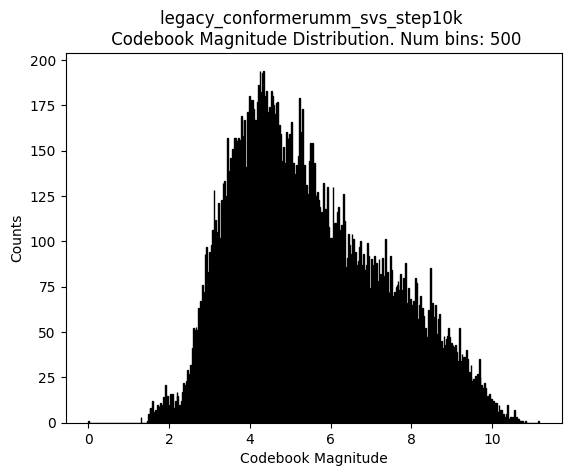

In [163]:
NUM_BINS=500
plt.hist(codebook_mags, bins=NUM_BINS, color='skyblue', edgecolor='black')
plt.xlabel('Codebook Magnitude')
plt.ylabel('Counts')
plt.title(f"{MODEL_KEY} \n Codebook Magnitude Distribution. Num bins: {NUM_BINS}")
plt.show()

In [164]:
# Get the unique values and their counts
unique_values, counts = np.unique(codebook_mags, return_counts=True)

# Print the results
cnt = 0
for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")
    cnt+=1
    if cnt > 10:
        break

0.0 occurs 1 times
1.3042676448822021 occurs 1 times
1.310099720954895 occurs 1 times
1.3148192167282104 occurs 1 times
1.4525823593139648 occurs 1 times
1.4737542867660522 occurs 1 times
1.4891093969345093 occurs 1 times
1.4893649816513062 occurs 1 times
1.489872932434082 occurs 1 times
1.4899626970291138 occurs 1 times
1.5090916156768799 occurs 1 times
